# pypasi 

A self-contained introduction to `pypasi`, the band-resolved audit layer for Raman classifiers described in the accompanying SoftwareX paper. It needs
**no data download**: everything runs on the synthetic cohort the package ships. Expect a
couple of minutes end to end.

**What it does.** It drives the whole library — the band ensemble, the external audit, the
control chart, the triage policy and the report objects — and then runs three tests:

1. **Determinism.** Fitting the same data twice gives bit-identical models.
2. **Patient-level leakage.** What splitting by spectrum instead of by patient costs you.
3. **Reference-batch design.** What happens to a control chart when a batch is not a patient.

The last two are methodological results that hold for any cohort with repeated measurements
per specimen, and they are the spine of the follow-up paper on laboratory procedure. The
final section sketches what else that paper will cover.


---

## 1 · Setup

`pypasi` is pure Python on top of NumPy, SciPy, pandas and scikit-learn. Version **0.5.3**
or later matters here: earlier releases built their PCA without fixing the solver, so the
novelty statistics drew from the global NumPy stream and results depended on the order in
which cells had been run. Section 6 is the test that now guards it.

In [13]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

import pypasi
from pypasi import BandNegotiationClassifier, ControlProfile, PLSDA, Triage, audit_external
from pypasi.datasets import make_conflict_signals

warnings.filterwarnings("ignore", category=FutureWarning)
_v = tuple(int(p) for p in pypasi.__version__.split(".")[:3])
assert _v >= (0, 5, 3), f"this tour needs pypasi >= 0.5.3, found {pypasi.__version__}"

SEED = 0
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.edgecolor": "#e7e6e2", "axes.labelcolor": "#52514e",
                     "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.dpi": 110})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#7c7b76"
print("pypasi", pypasi.__version__)

pypasi 0.5.3


## 2 · A cohort with patients in it

The packaged generator makes spectra with informative peaks and one deliberately
*conflicting* region, which is what the method is built to notice. On top of that the cell
below imposes the structure a clinical cohort really has: **each patient contributes many
spectra and carries one class**, and each patient gets a small multiplicative and additive
offset of their own.

In [26]:
N_PATIENTS, PER_PATIENT, N_CLASSES, N_POINTS, N_BANDS = 24, 60, 3, 500, 6
rng = np.random.default_rng(SEED)

X, y, axis, _ = make_conflict_signals(
    n_samples=N_PATIENTS * PER_PATIENT, n_classes=N_CLASSES, n_points=N_POINTS,
    signal_strength=0.50, noise=0.45, conflict_rate=0.35, random_state=SEED)

# Carve patients out of each class block, so no patient ever spans two classes.
keep, patient, nxt = [], [], 0
for c in sorted(set(y)):
    idx = np.flatnonzero(y == c)
    for j in range(len(idx) // PER_PATIENT):
        keep.append(idx[j * PER_PATIENT:(j + 1) * PER_PATIENT])
        patient.append(np.full(PER_PATIENT, nxt))
        nxt += 1
keep, patient = np.concatenate(keep), np.concatenate(patient)
X, y, N_PATIENTS = X[keep], y[keep], nxt

# A per-patient offset: this is the between-specimen variance a control chart has
# to distinguish instrument drift from.
for p in range(N_PATIENTS):
    m = patient == p
    X[m] *= 1.0 + rng.normal(0, 0.04)
    X[m] += rng.normal(0, 0.015, (1, N_POINTS))

# Three patient-disjoint roles, exactly as the study splits its cohort.
pats = rng.permutation(N_PATIENTS)
n_f, n_l = int(0.5 * N_PATIENTS), int(0.25 * N_PATIENTS)
p_fit, p_lim, p_qc = pats[:n_f], pats[n_f:n_f + n_l], pats[n_f + n_l:]
rows = lambda ps: np.flatnonzero(np.isin(patient, ps))
i_fit, i_lim, i_qc = rows(p_fit), rows(p_lim), rows(p_qc)

assert len(set(zip(patient, y))) == N_PATIENTS, "a patient spans two classes"
assert not (set(p_fit) & set(p_qc)), "patient appears in two splits"
print(f"{len(X)} spectra | {N_PATIENTS} patients | {N_CLASSES} classes")
print(f"fit {len(i_fit)} | limits {len(i_lim)} | held-out {len(i_qc)} spectra, "
      f"from {len(p_fit)}/{len(p_lim)}/{len(p_qc)} disjoint patients")

1380 spectra | 23 patients | 3 classes
fit 660 | limits 300 | held-out 420 spectra, from 11/5/7 disjoint patients


## 3 · Fit the band ensemble

`BandNegotiationClassifier` partitions the axis, fits one base estimator per band, and
reconciles their class evidence by negotiation. It follows the scikit-learn protocol, so it
drops into a `Pipeline` or a cross-validator unchanged, and the base estimator is a
constructor argument with no constraints on what it is.

In [27]:
clf = BandNegotiationClassifier(
    axis=axis, n_bands=N_BANDS, regime="H1", topology="complete",
    base_estimator=PLSDA(n_components=8), random_state=SEED,
).fit(X[i_fit], y[i_fit])

EDGES = [(b.lo, b.hi) for b in clf.bands_.bands]
LAB = [b.label for b in clf.bands_.bands]
acc = accuracy_score(y[i_qc], clf.predict(X[i_qc]))
print(f"held-out accuracy (patient-disjoint): {acc:.3f}")
print("bands: " + " | ".join(f"{l} {lo:.0f}-{hi:.0f}" for l, (lo, hi) in zip(LAB, EDGES)))

held-out accuracy (patient-disjoint): 0.786
bands: B1 400-633 | B2 633-867 | B3 867-1100 | B4 1100-1333 | B5 1333-1567 | B6 1567-1800


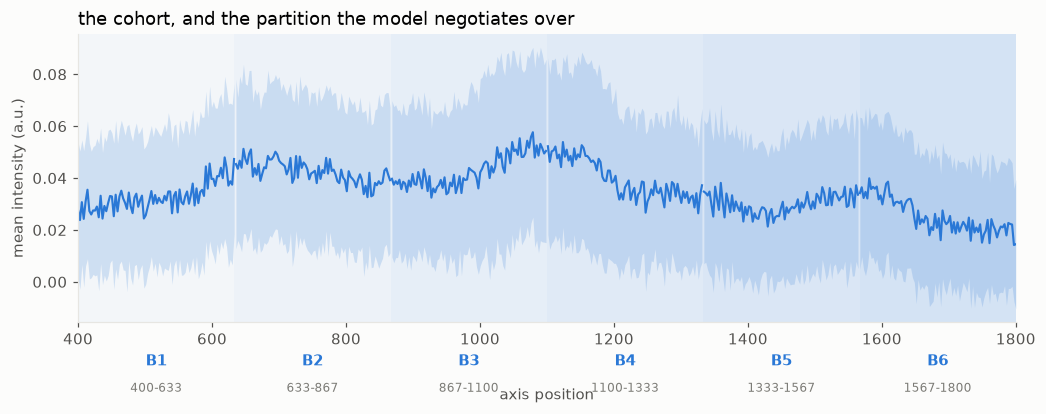

In [28]:
fig, ax = plt.subplots(figsize=(11, 3.4))
mu, sd = X.mean(0), X.std(0)
for j, (lo, hi) in enumerate(EDGES):
    ax.axvspan(lo, hi, color=BLUE, alpha=0.04 + 0.03 * j, lw=0)
    m = (axis >= lo) & (axis <= hi)
    ax.fill_between(axis[m], (mu - sd)[m], (mu + sd)[m], color=BLUE, alpha=0.18, lw=0)
    ax.plot(axis[m], mu[m], color=BLUE, lw=1.4)
    ax.annotate(LAB[j], (0.5 * (lo + hi), -0.11), xycoords=("data", "axes fraction"),
                ha="center", va="top", fontweight="bold", color=BLUE, fontsize=10)
    ax.annotate(f"{lo:.0f}-{hi:.0f}", (0.5 * (lo + hi), -0.21),
                xycoords=("data", "axes fraction"), ha="center", va="top",
                color=GREY, fontsize=8)
ax.set_xlim(axis.min(), axis.max())
ax.set_ylabel("mean intensity (a.u.)")
ax.set_xlabel("axis position", labelpad=26)
ax.set_title("the cohort, and the partition the model negotiates over", loc="left")
plt.show()

## 4 · The three ways to use it

The paper describes three entry points, and they differ in how much of an existing workflow
they replace. All three appear below.

### (a) The ensemble as the classifier

`audit()` returns the prediction together with the negotiation trajectories and the
descriptors derived from them. `summary()` is **one row per spectrum**, which is the record
a laboratory files.

In [29]:
au = clf.audit(X[i_qc], y[i_qc])
print(au.summary().head(4).to_string(index=False))
print("\ncolumns:", ", ".join(au.summary().columns))

 sample  y_pred  confidence        DG  DG_early     REDG    eREDG  n_muted_bands  mean_mute_fraction  max_band_stress worst_band  y_true  correct
      0       0    0.985058 33.476976 32.152635 0.960440 0.960440              5            0.038889         0.022446         B1       0        1
      1       0    0.999942 28.959151 25.361969 0.875784      NaN              2            0.011111         0.001457         B2       0        1
      2       0    0.999829 25.490127 22.538950 0.884223      NaN              2            0.011111         0.011707         B6       0        1
      3       0    0.996762 33.670255 29.826328 0.885836 0.885836              4            0.022222         0.001717         B4       0        1

columns: sample, y_pred, confidence, DG, DG_early, REDG, eREDG, n_muted_bands, mean_mute_fraction, max_band_stress, worst_band, y_true, correct


### (b) The external audit — predictions left untouched

This is the mode that matters for adoption. A laboratory with a validated classifier cannot
revalidate it, so the audit wraps the fitted model and returns its conflict, novelty and
worst-interval columns **beside** the host's own output. The assertion below is the point:
the host's predictions are identical, by construction.

In [30]:
host = PLSDA(n_components=8).fit(X[i_fit], y[i_fit])
ext = audit_external(host, X[i_fit], y[i_fit], axis=axis, n_bands=N_BANDS,
                     random_state=SEED)

assert np.array_equal(host.predict(X[i_qc]), ext.predict(X[i_qc])), \
    "the external audit changed the host's predictions"
print("host predictions unchanged by the audit:", True)
print(ext.explain(X[i_qc][:4]).to_string(index=False))

host predictions unchanged by the audit: True
 host_prediction  band_prediction  agreement  host_confidence  conflict  mean_stress  novelty worst_band  worst_band_axis_lo  worst_band_axis_hi
               0                0       True         0.420389  0.021160     0.007416 1.405356         B1          400.000000          633.333333
               0                0       True         0.498005  0.000000     0.000852 1.158141         B4         1100.000000         1333.333333
               0                0       True         0.469284  0.051442     0.004572 1.412260         B6         1566.666667         1800.000000
               0                0       True         0.479913  0.061606     0.002349 1.235953         B3          866.666667         1100.000000


### (c) The control chart, for batches rather than spectra

`ControlProfile` turns the per-band behaviour of a fitted model on reference batches into
limits, and `check()` scores a new batch against them. The report names which band-level
statistic moved, which is the difference between an alert and an instruction.

Note the warning the library raises. Five reference batches is a thin basis for a standard
deviation, and the chart says so rather than quietly producing limits that look confident.

In [31]:
def batches_by_patient(ps, n=50, seed=1):
    r = np.random.default_rng(seed)
    return [X[np.sort(r.choice(np.flatnonzero(patient == p), n, replace=False))]
            for p in ps]

profile = ControlProfile.fit(clf, batches=batches_by_patient(p_lim), k=3.0,
                             random_state=SEED)
report = profile.check(batches_by_patient(p_qc, seed=7)[0], name="patient-A")
print(report.summary())
print()
print(report.table.head(4).round(3).to_string(index=False))

C:\Users\nikos\AppData\Local\Temp\ipykernel_15400\76219030.py:6: UserWarning: only 5 reference batches: the standard deviation behind these limits is poorly determined. Consider method='quantile', which assumes nothing about the distribution.
  profile = ControlProfile.fit(clf, batches=batches_by_patient(p_lim), k=3.0,


patient-A: 50 spectra, 0 of 12 band-statistics outside 3.68886 sigma  IN CONTROL

  statistic label  axis_lo  axis_hi  centre    sd    lcl   ucl  value     z  out_of_control
mean_stress    B1  400.000  633.333   0.009 0.005 -0.009 0.028  0.011 0.416           False
mean_stress    B2  633.333  866.667   0.006 0.007 -0.020 0.031  0.015 1.281           False
mean_stress    B3  866.667 1100.000   0.007 0.006 -0.014 0.029  0.009 0.344           False
mean_stress    B4 1100.000 1333.333   0.005 0.004 -0.008 0.018  0.008 0.767           False


## 5 · The mechanism, one spectrum at a time

Before any statistics: what does band disagreement actually detect? The cell below damages
**one known band** of a single spectrum and asks the audit which band it found hardest to
reconcile. Chance is one in six.

Defects go only into bands that carry class information. A band with no signal in it has
nothing to disagree about, and planting there would measure the generator rather than the
method.

This is a demonstration of the mechanism, not the paper's detection result. The paper's
numbers are in section 9.

In [32]:
SIG = float(np.median(np.abs(np.diff(X, axis=1)))) * 3     # a local noise scale
INFORMATIVE = [i for i, (lo, hi) in enumerate(EDGES)
               if any(lo <= c < hi for c in (700, 900, 1100, 1300, 1550))]

def dent(Xc, band, severity, rng):
    """Attenuate and roughen one band: a substrate peak, a contaminated well."""
    Xc = np.asarray(Xc, float).copy()
    lo, hi = EDGES[band]
    sel = (axis >= lo) & (axis < hi)
    Xc[:, sel] = (Xc[:, sel] * np.exp(-1.6 * severity)
                  + rng.normal(0, 2.5 * severity * SIG, (len(Xc), int(sel.sum()))))
    return Xc

r = np.random.default_rng(11)
hits = []
for b in INFORMATIVE:
    for _ in range(12):
        i = r.choice(i_qc)
        named = clf.audit(dent(X[i][None], b, 1.0, r)).summary()["worst_band"].iloc[0]
        hits.append({"planted": LAB[b], "named": named, "hit": named == LAB[b]})
hits = pd.DataFrame(hits)
print(f"the audit names the damaged band in {hits['hit'].mean():.0%} of {len(hits)} "
      f"trials, against a chance rate of {1 / N_BANDS:.0%}")
print()
print(pd.crosstab(hits["planted"], hits["named"]).to_string())

the audit names the damaged band in 48% of 48 trials, against a chance rate of 17%

named    B1  B2  B3  B4  B5  B6
planted                        
B2        0   5   2   2   2   1
B3        2   2   6   2   0   0
B4        2   2   0   5   2   1
B5        0   0   1   3   7   1


## 6 · Test 1 — the same data gives the same model

A quality-control record that cannot be regenerated is not a record. `pypasi` 0.5.2 failed
this test: `NoveltyDetector` and `PCALDA` built their `PCA` without a solver or a seed, and
scikit-learn's `svd_solver="auto"` picks the *randomized* solver at spectroscopic shapes,
which draws from the global NumPy stream. Two fits of one cohort returned different limits
depending on how much unrelated code had run first.

0.5.3 computes the decomposition exactly. The test below drains a different amount of the
global stream between two fits; before the fix, that alone changed the answer.

In [33]:
from pypasi import NoveltyDetector

def fit_after(n_draws):
    np.random.seed(4321)
    np.random.random(n_draws)                 # stand in for "whatever ran before"
    return NoveltyDetector(n_components=8).fit(X[i_fit])

a, b = fit_after(0), fit_after(5000)
same = (a.spe_threshold_ == b.spe_threshold_
        and a.t2_threshold_ == b.t2_threshold_
        and np.array_equal(a.pca_.components_, b.pca_.components_))
print(f"Q residual limit   {a.spe_threshold_:.9f}   {b.spe_threshold_:.9f}")
print(f"Hotelling T2 limit {a.t2_threshold_:.9f}   {b.t2_threshold_:.9f}")
print(f"\nidentical: {same}")
assert same, "the novelty limits depend on execution order"
print("PASS  the limits do not depend on what ran before them")

Q residual limit   440.990749779   440.990749779
Hotelling T2 limit 12.311157955   12.311157955

identical: True
PASS  the limits do not depend on what ran before them


## 7 · Test 2 — what splitting by spectrum costs

Every spectrum in this cohort belongs to a patient, and patients contribute many spectra.
Split the cohort at random and most patients appear on both sides of the split, so the model
can recognise the patient rather than the class. The accuracy that comes back is a
re-identification score wearing a classifier's clothes.

The same test on the real bacterial cohort in the paper gives **0.948 against 0.877, a gap
of 7.1 accuracy points**. The synthetic gap below is larger because the patient offsets here
are cleaner than biology, but the direction and the cause are the same.

In [34]:
r = np.random.default_rng(3)
perm = r.permutation(len(X))
leak_fit, leak_eval = perm[:len(i_fit)], perm[len(i_fit):len(i_fit) + len(i_qc)]

leaky = BandNegotiationClassifier(
    axis=axis, n_bands=N_BANDS, regime="H1", topology="complete",
    base_estimator=PLSDA(n_components=8), random_state=SEED,
).fit(X[leak_fit], y[leak_fit])

a_leak = accuracy_score(y[leak_eval], leaky.predict(X[leak_eval]))
a_pat = accuracy_score(y[i_qc], clf.predict(X[i_qc]))
shared = len(set(patient[leak_fit]) & set(patient[leak_eval]))
print(f"patients on both sides of the random split: {shared} of {N_PATIENTS}")
print(f"\nsplit by spectrum : {a_leak:.3f}")
print(f"split by patient  : {a_pat:.3f}")
print(f"difference        : {100 * (a_leak - a_pat):+.1f} accuracy points of leakage")

patients on both sides of the random split: 23 of 23

split by spectrum : 1.000
split by patient  : 0.786
difference        : +21.4 accuracy points of leakage


## 8 · Test 3 — a batch has to be a patient

This is the single most consequential choice in the batch section of the study, and the
first version of that analysis got it wrong in an instructive way.

Reference batches for a control chart must be drawn the way real batches arrive: **one
batch, one specimen**. Build them instead by interleaving spectra from every reference
patient, and each batch contains a little of everyone, so the between-batch variance the
limits are calibrated on contains no between-patient variance at all. The limits come out
far too tight, and every batch from a new patient trips them.

The comparison below charts the same clean, unseen patients against both constructions.

In [35]:
def batches_interleaved(ps, n=50, k=6):
    idx = np.flatnonzero(np.isin(patient, ps))
    return [X[idx[i::k]][:n] for i in range(k)]

clean = batches_by_patient(p_qc, seed=7)          # unseen patients, no defect at all
out = []
for label, ref in [("one batch per patient", batches_by_patient(p_lim)),
                   ("interleaved across patients", batches_interleaved(p_lim))]:
    prof = ControlProfile.fit(clf, batches=ref, k=3.0, random_state=SEED)
    flagged = [prof.check(b).drift_score > prof.k_effective for b in clean]
    out.append({"reference batches": label,
                "limit (k_effective)": round(prof.k_effective, 2),
                "clean patients flagged": f"{sum(flagged)}/{len(flagged)}",
                "false-alarm rate": round(float(np.mean(flagged)), 2)})
print(pd.DataFrame(out).to_string(index=False))
print("\nBoth charts are correct code on the same model and the same spectra.")
print("Only the definition of a reference batch differs.")

C:\Users\nikos\AppData\Local\Temp\ipykernel_15400\4052236891.py:9: UserWarning: only 5 reference batches: the standard deviation behind these limits is poorly determined. Consider method='quantile', which assumes nothing about the distribution.
  prof = ControlProfile.fit(clf, batches=ref, k=3.0, random_state=SEED)
C:\Users\nikos\AppData\Local\Temp\ipykernel_15400\4052236891.py:9: UserWarning: only 6 reference batches: the standard deviation behind these limits is poorly determined. Consider method='quantile', which assumes nothing about the distribution.
  prof = ControlProfile.fit(clf, batches=ref, k=3.0, random_state=SEED)


          reference batches  limit (k_effective) clean patients flagged  false-alarm rate
      one batch per patient                 3.69                    0/7               0.0
interleaved across patients                 3.69                    7/7               1.0

Both charts are correct code on the same model and the same spectra.
Only the definition of a reference batch differs.


In [36]:
tri = Triage(conflict_score="dg", review_rate=0.10, n_components=8).fit(
    clf, X[i_lim], y[i_lim])
T = tri.assess(X[i_qc], y[i_qc]).table

print(f"flagged novel      : {T['is_novel'].mean():.0%} of held-out spectra")
print(f"flagged conflicted : {T['is_conflicted'].mean():.0%}")
print()
act = (T.groupby("action")
        .agg(n=("sample", "size"), accuracy=("correct", "mean"))
        .reindex(["accept", "review", "remeasure", "reject"]).dropna(how="all"))
act["share"] = (act["n"] / len(T)).round(3)
print(act.round(3).to_string())
print(f"\ncohort accuracy {T['correct'].mean():.3f}")

flagged novel      : 100% of held-out spectra
flagged conflicted : 16%

               n  accuracy  share
action                           
remeasure  352.0     0.827  0.838
reject      68.0     0.574  0.162

cohort accuracy 0.786


**The outlier test has saturated, and the disagreement test has not.**

Every held-out spectrum is called novel, because every held-out *patient* is a specimen the
novelty model has never seen and the per-patient offsets put all of them outside its
envelope. Five calibration patients cannot describe a sixth. The study reports the same
thing about its external cohort: under a patient-disjoint split a novelty test lights up end
to end and stops discriminating.

Inter-band conflict, computed on the same spectra by the same object, still separates a
sixth of them. That is also the paper's argument: novelty asks whether a
spectrum *resembles the reference set*, conflict asks whether its own regions *agree about
what it is*, and the two come apart exactly when it matters. A familiar-looking spectrum can
deserve review because its regions disagree; an unfamiliar one can still be perfectly
coherent.

The spectra conflict rejects are classified correctly 57%
of the time against 83% for the rest, so the flag carries information about the answer and
not only about the sample.
